Image Enhancement using Mathematical Operation

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
%matplotlib inline
import matplotlib

from IPython.display import Image

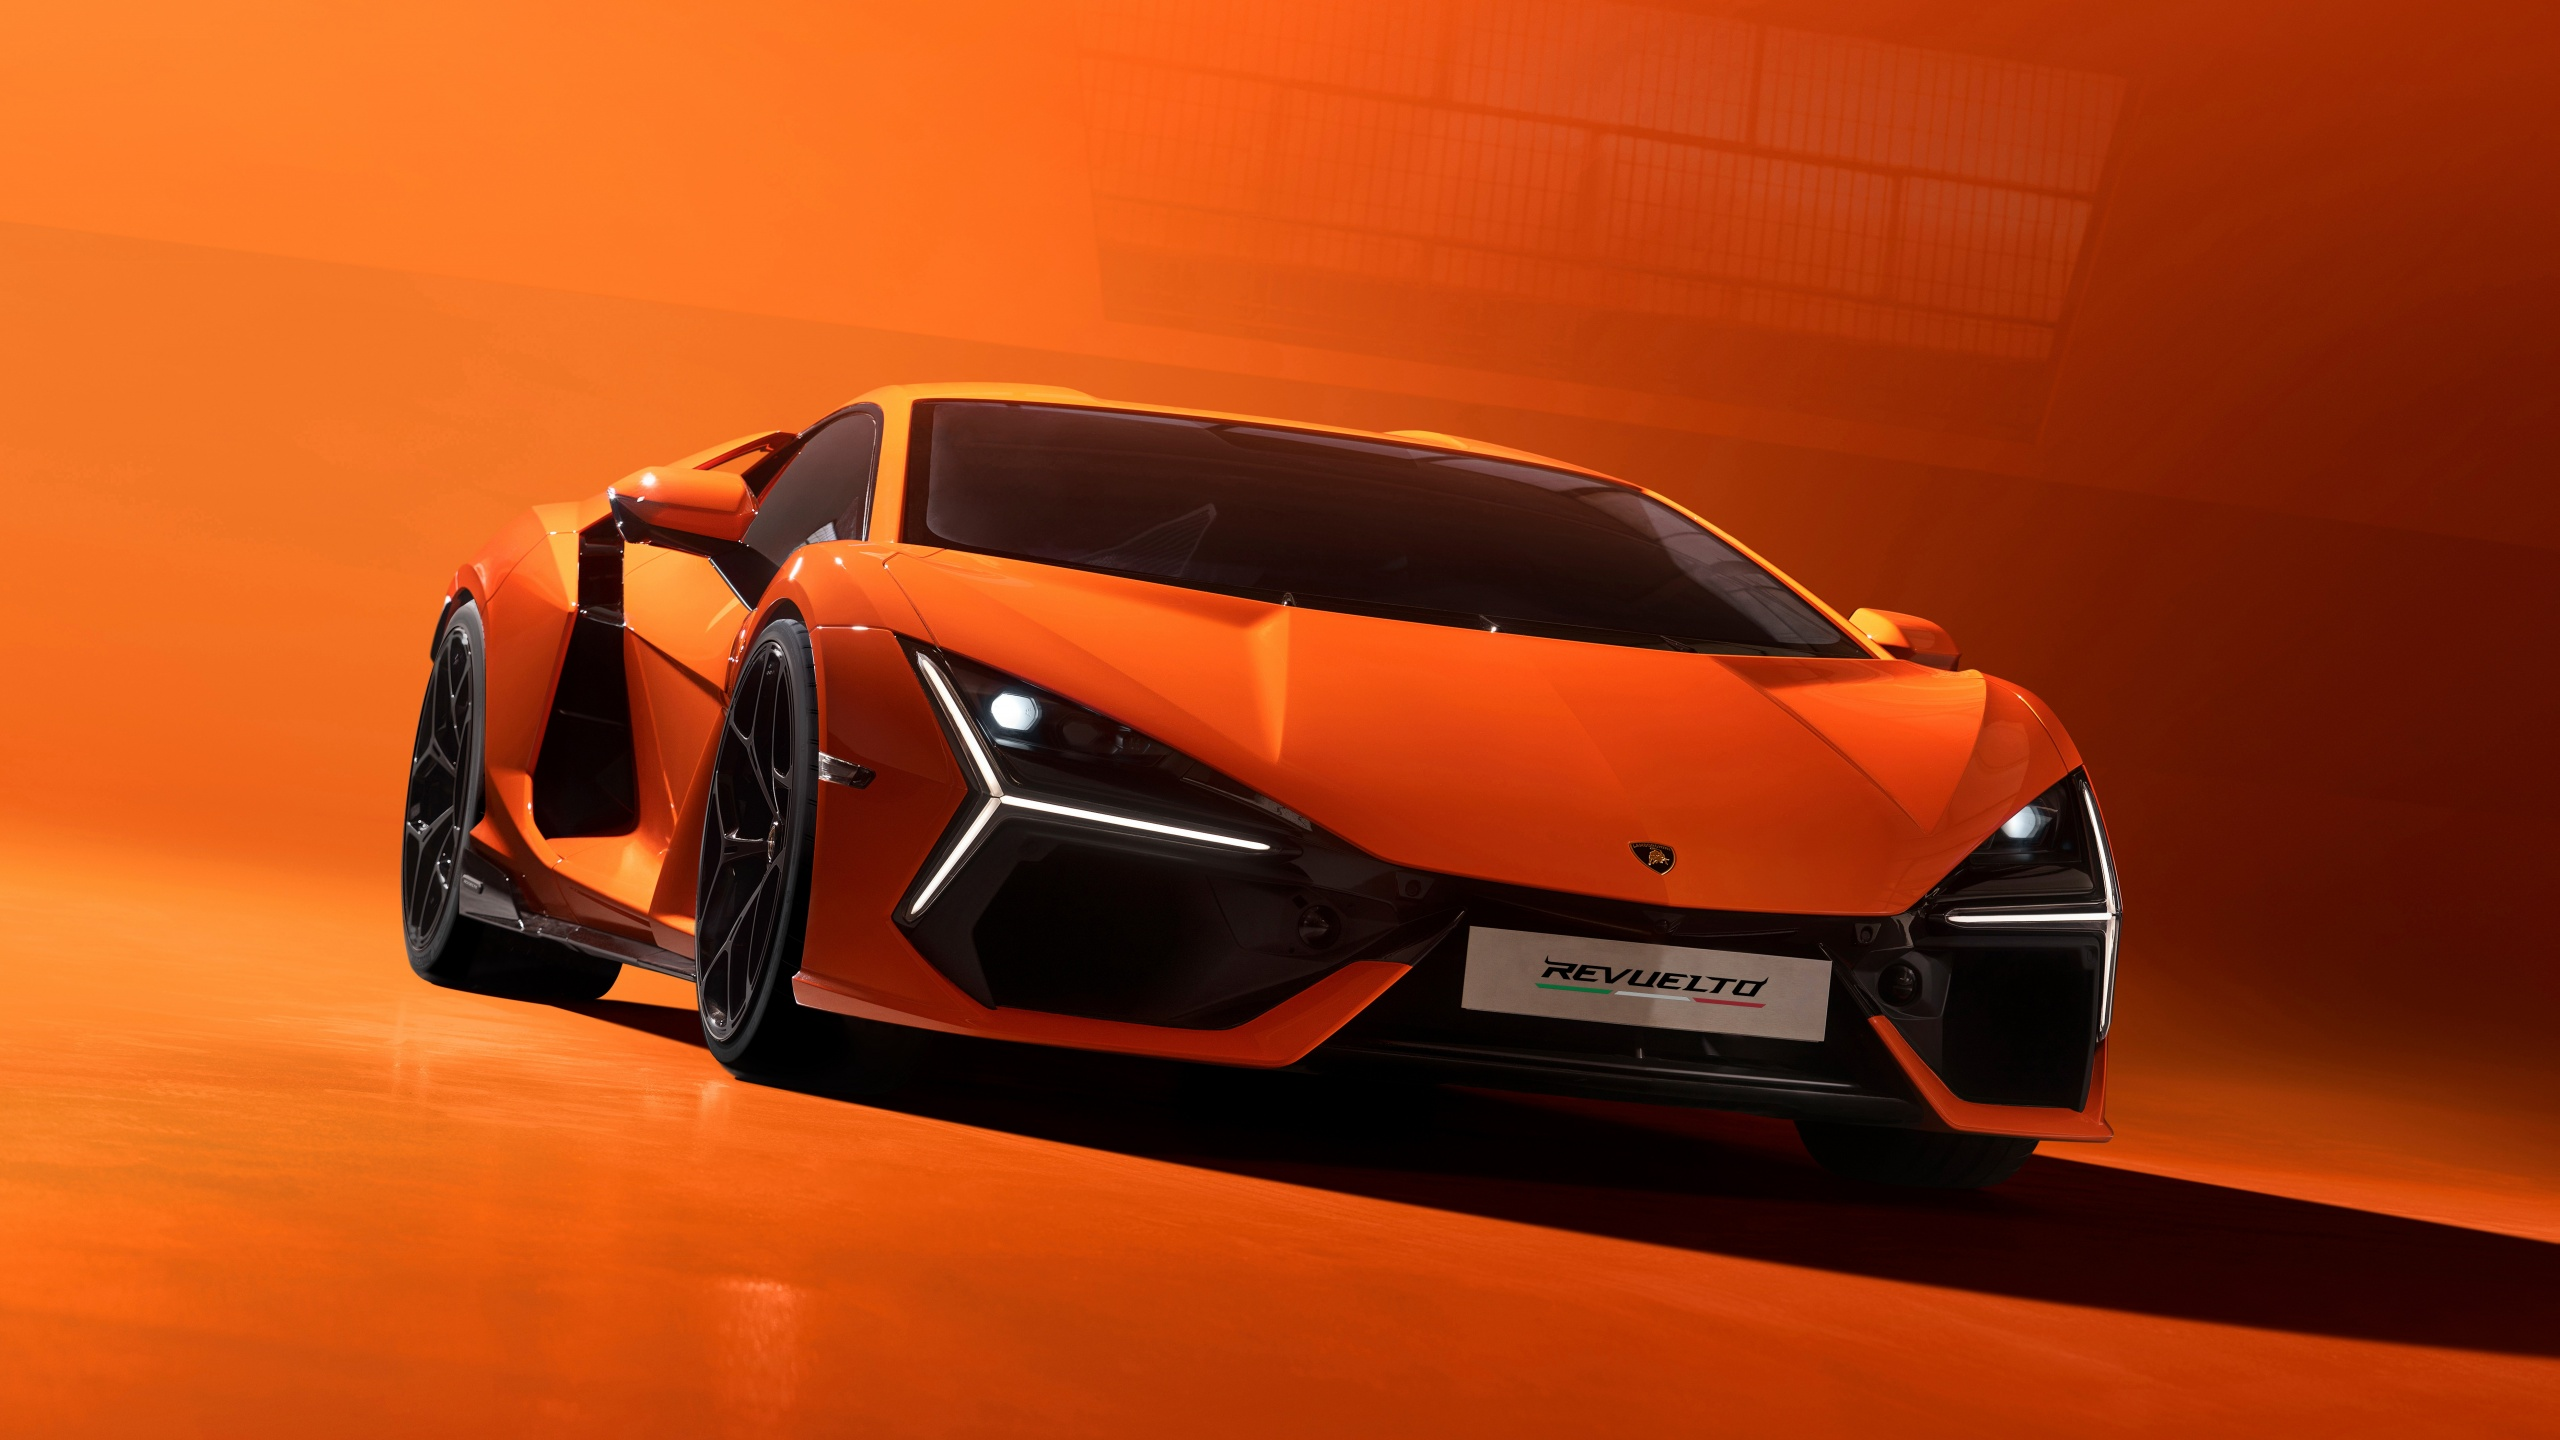

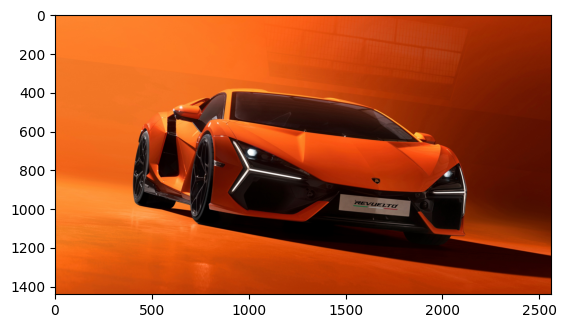

In [2]:
car=cv2.imread("car.jpeg",cv2.IMREAD_COLOR)
plt.imshow(car[:,:,::-1])
Image("car.jpeg")


Brightness of the image (Addition and subtraction)

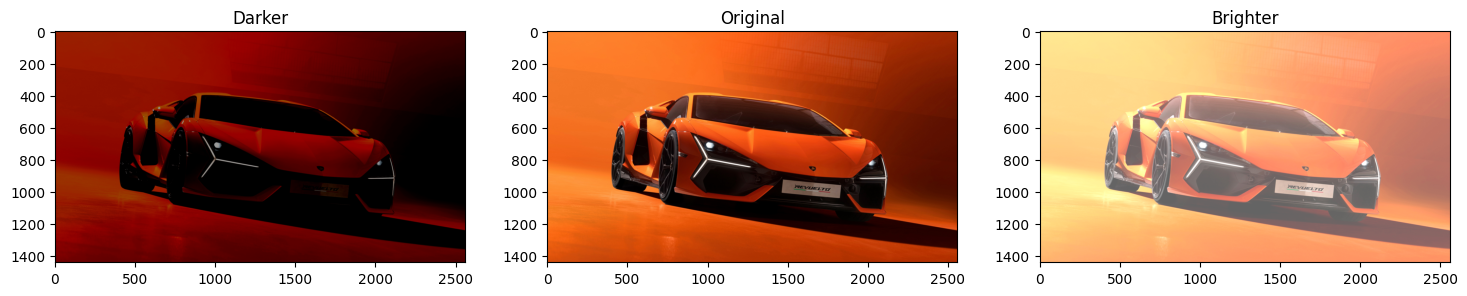

In [3]:
matrix=np.ones(car.shape,dtype=np.uint8)*100
#print(matrix)

car_bright=cv2.add(car,matrix)
car_dark=cv2.subtract(car,matrix)

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.title("Darker")
plt.imshow(car_dark[:,:,::-1])

plt.subplot(1,3,2)
plt.title("Original")
plt.imshow(car[:,:,::-1])

plt.subplot(1,3,3)
plt.title("Brighter")   
plt.imshow(car_bright[:,:,::-1])

Contrast (Multiplication)

In [4]:
matrix1=np.ones(car.shape)*.8
matrix2=np.ones(car.shape)*1.2

car_dark2=np.uint8(cv2.multiply(np.float64(car),matrix1))
car_bright2=np.uint8(cv2.multiply(np.float64(car),matrix2))

Text(0.5, 1.0, 'Brighter')

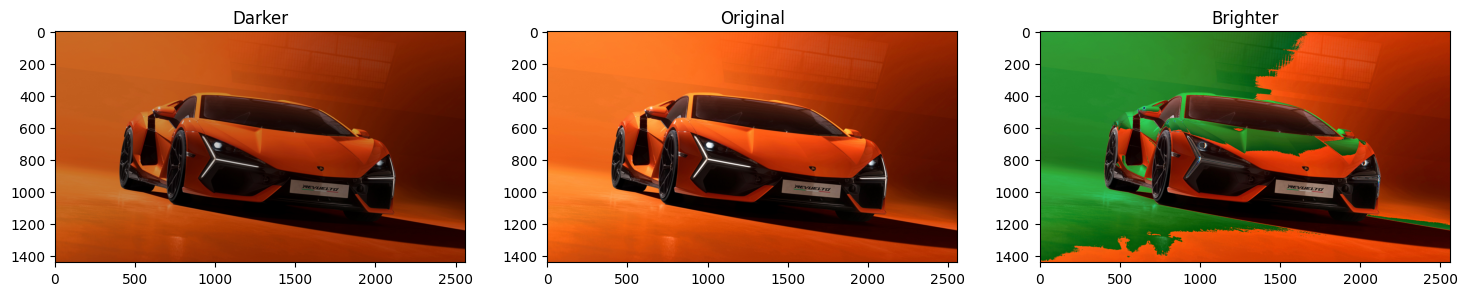

In [5]:
plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(car_dark2[:,:,::-1])
plt.title("Darker")    

plt.subplot(1,3,2)
plt.imshow(car[:,:,::-1])       
plt.title("Original") 

plt.subplot(1,3,3)
plt.imshow(car_bright2[:,:,::-1])
plt.title("Brighter")

Text(0.5, 1.0, 'Brighter')

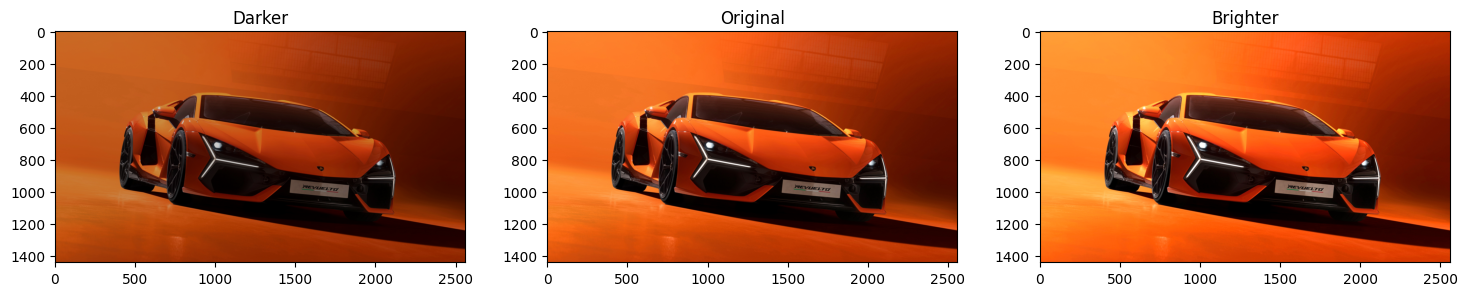

In [6]:
#as the 1.2 factor matrix multiplied with colour matric ,the valyes exceed 255 and the result is 255 which is the maximum value for a pixel in an image. So the image appears brighter but with less contrast. The same applies to the darker image where the values are multiplied by 0.8, resulting in values that are less than 255, making the image appear darker but with less contrast.
#for not exceeding the maximum value of 255, we can use np.clip() function which allows us to specify the weights for the original image and the added matrix, ensuring that the resulting pixel values do not exceed 255. This way, we can achieve a brighter or darker image without losing contrast.
#
car_dark2=np.uint8(cv2.multiply(np.float64(car),matrix1))
car_bright2=np.uint8(np.clip(cv2.multiply(np.float64(car),matrix2), 0, 255))

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.imshow(car_dark2[:,:,::-1])
plt.title("Darker")    

plt.subplot(1,3,2)
plt.imshow(car[:,:,::-1])       
plt.title("Original") 

plt.subplot(1,3,3)
plt.imshow(car_bright2[:,:,::-1])
plt.title("Brighter")

Image thresholding:
for  image eprocessing an masking

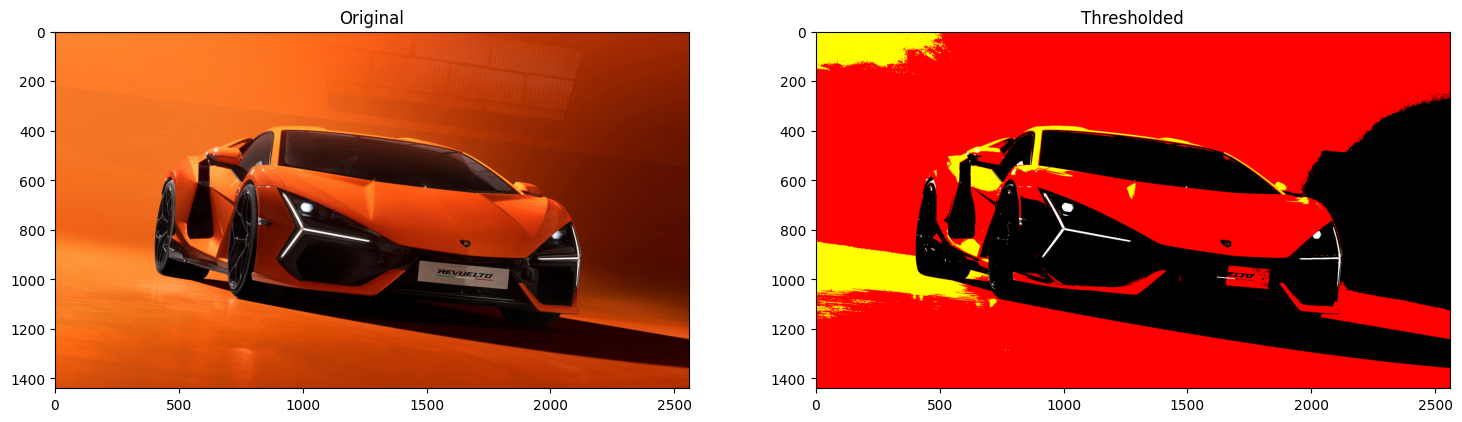

In [8]:
img_car=cv2.imread("car.jpeg",cv2.IMREAD_COLOR)

retval,car_thresh=cv2.threshold(img_car,127,255,cv2.THRESH_BINARY)

plt.figure(figsize=(18,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(img_car[:,:,::-1])

plt.subplot(1,2,2)
plt.title("Thresholded")
plt.imshow(car_thresh[:,:,::-1])

Application:Sheet music Reader

specially used for decode or read sheet music .similar to OCR to get text from etxt document.

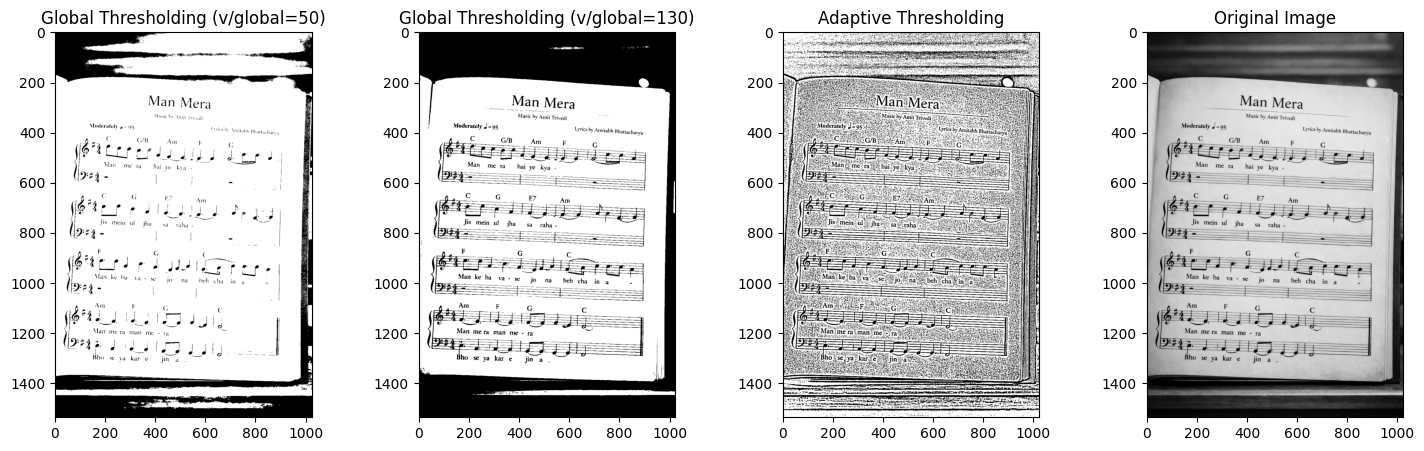

In [13]:
music_img=cv2.imread("music_sheet.png",cv2.IMREAD_GRAYSCALE)
#print (music_img)
#global thresholding
retval,thresh1=cv2.threshold(music_img,50,255,cv2.THRESH_BINARY)

#global thresholding 
retval,thresh2=cv2.threshold(music_img,130,255,cv2.THRESH_BINARY)

#adaptive thresholding
thresh3=cv2.adaptiveThreshold(music_img,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,2)

plt.figure(figsize=(18,5))
plt.subplot(1,4,1)
plt.title("Global Thresholding (v/global=50)")
plt.imshow(thresh1,cmap="gray")

plt.subplot(1,4,2)
plt.title("Global Thresholding (v/global=130)")
plt.imshow(thresh2,cmap="gray")

plt.subplot(1,4,3)
plt.title("Adaptive Thresholding")  
plt.imshow(thresh3,cmap="gray")

plt.subplot(1,4,4)
plt.title("Original Image")
plt.imshow(music_img,cmap="gray")

plt.show()